In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv("Food_Delivery_Times.csv")

In [54]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [55]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


To address the `FutureWarning` and ensure the DataFrame is modified correctly, we will explicitly assign the filled column back to the DataFrame. This is the recommended way to perform such operations in pandas.

In [56]:
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])
df['Traffic_Level'] = df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0])
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

Let's re-check the null values to confirm everything is now handled without warnings.

In [57]:
df = df.drop('Order_ID', axis=1)
df.isnull().sum()

,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


### 1. Descriptive Statistics
Let's look at the summary of our numerical and categorical columns.

In [58]:
display(df.describe())
display(df.describe(include=['object']))

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.059970,16.982000,4.592000,56.732000
std,5.696656,7.204553,2.871198,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


,Weather,Traffic_Level,Time_of_Day,Vehicle_Type
count,1000,1000,1000,1000
unique,5,3,4,3
top,Clear,Medium,Morning,Bike
freq,500,420,338,503


### 2. Distribution of Target (Delivery_Time_min)
Visualizing the spread and identifying potential outliers in delivery times.

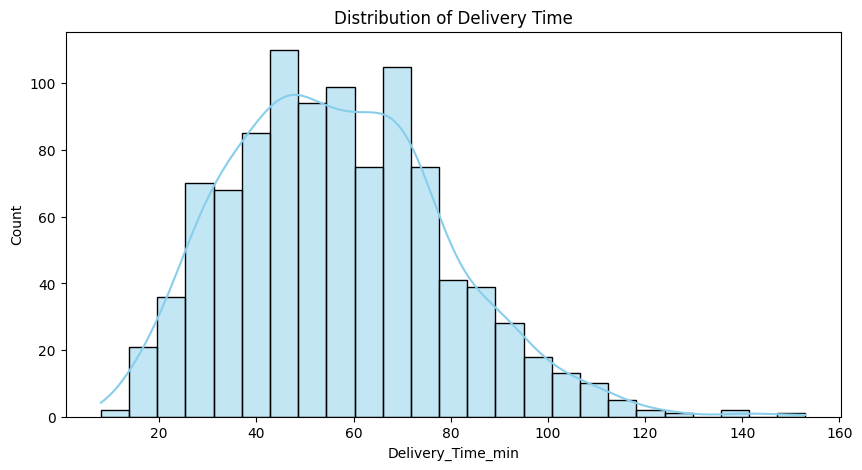

In [59]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Delivery_Time_min'], kde=True, color='skyblue')
plt.title('Distribution of Delivery Time')
plt.show()

### 3. Correlation Matrix
Checking linear relationships between numerical features.

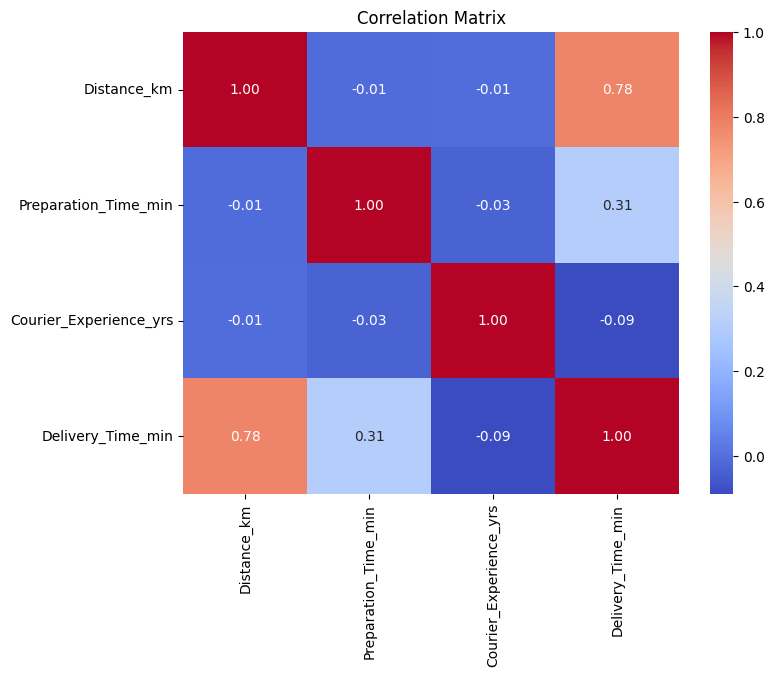

In [60]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### 4. Categorical Features vs Target
Analyzing how different categories affect delivery times.

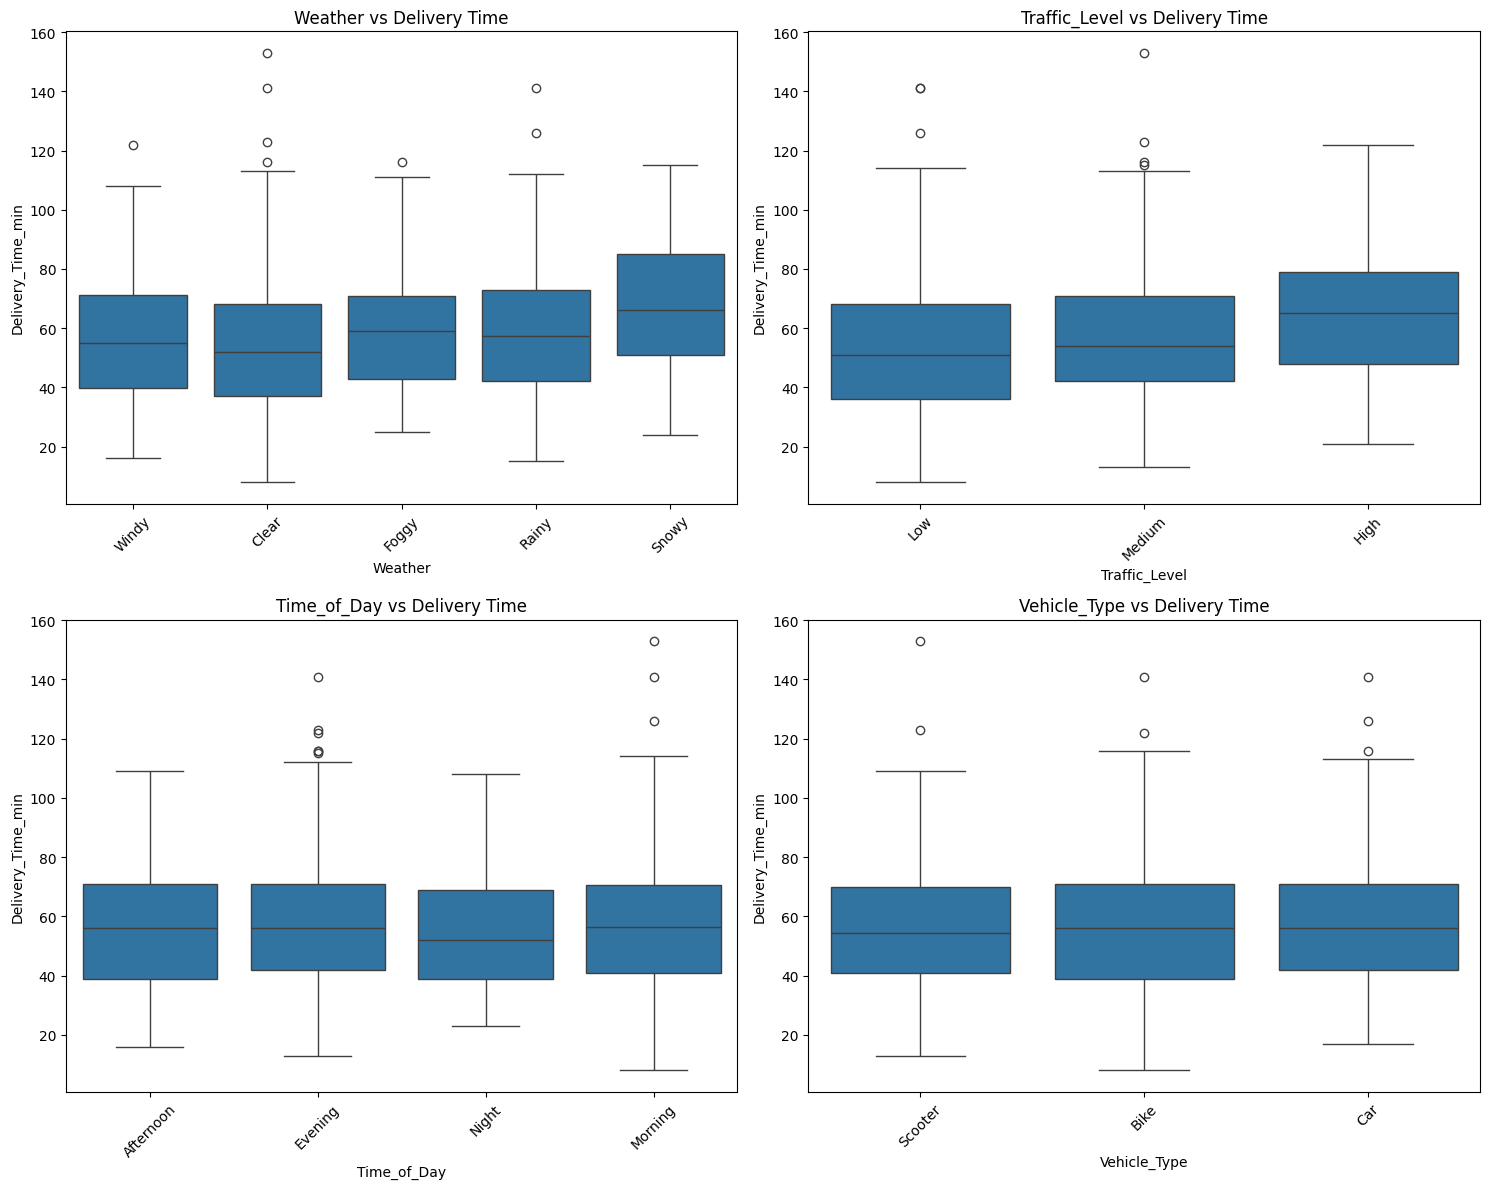

In [61]:
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y='Delivery_Time_min', data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Delivery Time')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Statistical Testing for Feature Selection
We will use correlation analysis for numerical variables and ANOVA for categorical variables to identify which features significantly influence `Delivery_Time_min`.

In [62]:
from scipy import stats

print("--- Correlation with Target (Numerical Features) ---")
numeric_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']
for col in numeric_cols:
    corr, p_val = stats.pearsonr(df[col], df['Delivery_Time_min'])
    print(f"{col}: Correlation={corr:.3f}, p-value={p_val:.4f}")

print("\n--- ANOVA Test (Categorical Features) ---")
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
for col in cat_cols:
    # Create groups for ANOVA
    groups = [group['Delivery_Time_min'].values for name, group in df.groupby(col)]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{col}: F-statistic={f_stat:.3f}, p-value={p_val:.4f}")

--- Correlation with Target (Numerical Features) ---
Distance_km: Correlation=0.781, p-value=0.0000
Preparation_Time_min: Correlation=0.307, p-value=0.0000
Courier_Experience_yrs: Correlation=-0.089, p-value=0.0048

--- ANOVA Test (Categorical Features) ---
Weather: F-statistic=10.499, p-value=0.0000
Traffic_Level: F-statistic=19.751, p-value=0.0000
Time_of_Day: F-statistic=0.347, p-value=0.7915
Vehicle_Type: F-statistic=0.589, p-value=0.5549


**Interpretation:**
- Features with a **p-value < 0.05** are considered statistically significant.
- High correlation coefficients or high F-statistics indicate stronger relationships with the delivery time.

### Label Encoding
Converting categorical features into numerical format using `LabelEncoder`.

In [63]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

display(df.head())

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68


### Data Splitting
We will now split the dataset into features ($X$) and the target variable ($y$), followed by splitting them into training and testing sets.

In [64]:
from sklearn.model_selection import train_test_split

# Defining features (X) and target (y)
X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']

# Splitting into Train and Test sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (800, 7)
Testing set shape: (200, 7)


### Decision Tree Model
We will now initialize and train a `DecisionTreeRegressor` without any hyperparameter tuning to establish a baseline.

In [65]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize the model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)

# Evaluate the model
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

R2 Score: 0.4940
MAE: 10.5600


### Random Forest Model (Baseline)
We will now train a Random Forest model to see if the ensemble approach improves our prediction metrics compared to the single Decision Tree.

In [66]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_rf_pred = rf_model.predict(X_test)

# Evaluate the model
print(f"Random Forest R2 Score: {r2_score(y_test, y_rf_pred):.2f}")
print(f"Random Forest MAE:      {mean_absolute_error(y_test, y_rf_pred):.4f}")

Random Forest R2 Score: 0.78
Random Forest MAE:      7.0646


### Hyperparameter Tuning for Random Forest
We use `RandomizedSearchCV` to explore a range of hyperparameters and find the best configuration for our dataset.

In [67]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the parameter grid using randint for a broader search range
# We use a wide range from small (50 trees, depth 5) to large (1000 trees, depth 50)
param_dist = {
    'n_estimators': randint(50, 1000),
    'max_depth': randint(5, 50),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Initialize RandomizedSearchCV with 100 iterations to explore the distribution
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    random_state=42,
    n_jobs=-1,
    scoring='r2'
)

# Fit the random search model
rf_random.fit(X_train, y_train)

# Get the best model
best_rf = rf_random.best_estimator_

print(f"Best Parameters: {rf_random.best_params_}")

Best Parameters: {'bootstrap': True, 'max_depth': 16, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 15, 'n_estimators': 719}


In [69]:
# Evaluate the newly tuned model from the broad search
y_tuned_pred = best_rf.predict(X_test)

print(f"Broad Search Best Parameters: {rf_random.best_params_}")
print(f"Tuned Random Forest R2 Score: {r2_score(y_test, y_tuned_pred):.2f}")
print(f"Tuned Random Forest MAE:      {mean_absolute_error(y_test, y_tuned_pred):.4f}")

Broad Search Best Parameters: {'bootstrap': True, 'max_depth': 16, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 15, 'n_estimators': 719}
Tuned Random Forest R2 Score: 0.78
Tuned Random Forest MAE:      6.9162
